# 📈 Báo cáo Phân tích và Dự báo Giá Cổ phiếu VIC (Vingroup)
**Phương pháp:** Phân tích Chuỗi thời gian (Time Series Analysis) với các mô hình AR, MA và ARIMA.

## 1. Giới thiệu dự án
Bài toán yêu cầu dự báo giá cổ phiếu VIC trong 10 ngày tiếp theo dựa trên dữ liệu lịch sử 1 năm gần nhất. Cổ phiếu là một chuỗi thời gian mang tính ngẫu nhiên cao, do đó quy trình phân tích sẽ tuân thủ nghiêm ngặt các bước học thuật:
1. Thu thập và Tiền xử lý dữ liệu.
2. Kiểm định tính dừng (Stationarity) bằng ADF Test.
3. Nhận diện tham số $p, q$ thông qua biểu đồ ACF và PACF.
4. Xây dựng mô hình Cơ sở (AR, MA) và mô hình Tối ưu (Auto-ARIMA).
5. Kiểm định phần dư (Residual Diagnostics) để đảm bảo độ tin cậy.
6. Dự báo tương lai và Đánh giá sai số (RMSE, MAE, MAPE).

In [1]:
# Cài đặt thư viện (nếu chưa có)
# !pip install yfinance pmdarima statsmodels pandas numpy matplotlib scikit-learn "numpy<2.0.0"

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện kiểm định thống kê và chuỗi thời gian
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Cấu hình hiển thị biểu đồ
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo đỏ để notebook sạch đẹp

## 2. Thu thập và Trực quan hóa dữ liệu
Sử dụng `yfinance` để lấy dữ liệu giá đóng cửa (Close price) của VIC. Dữ liệu tài chính thường chỉ giao dịch vào các ngày trong tuần (Business days).

⏳ Đang tải dữ liệu VIC.VN từ 27/05/2025 đến 27/05/2026...


[*********************100%***********************]  1 of 1 completed


✅ Đã tải thành công 249 ngày giao dịch của VIC.VN!


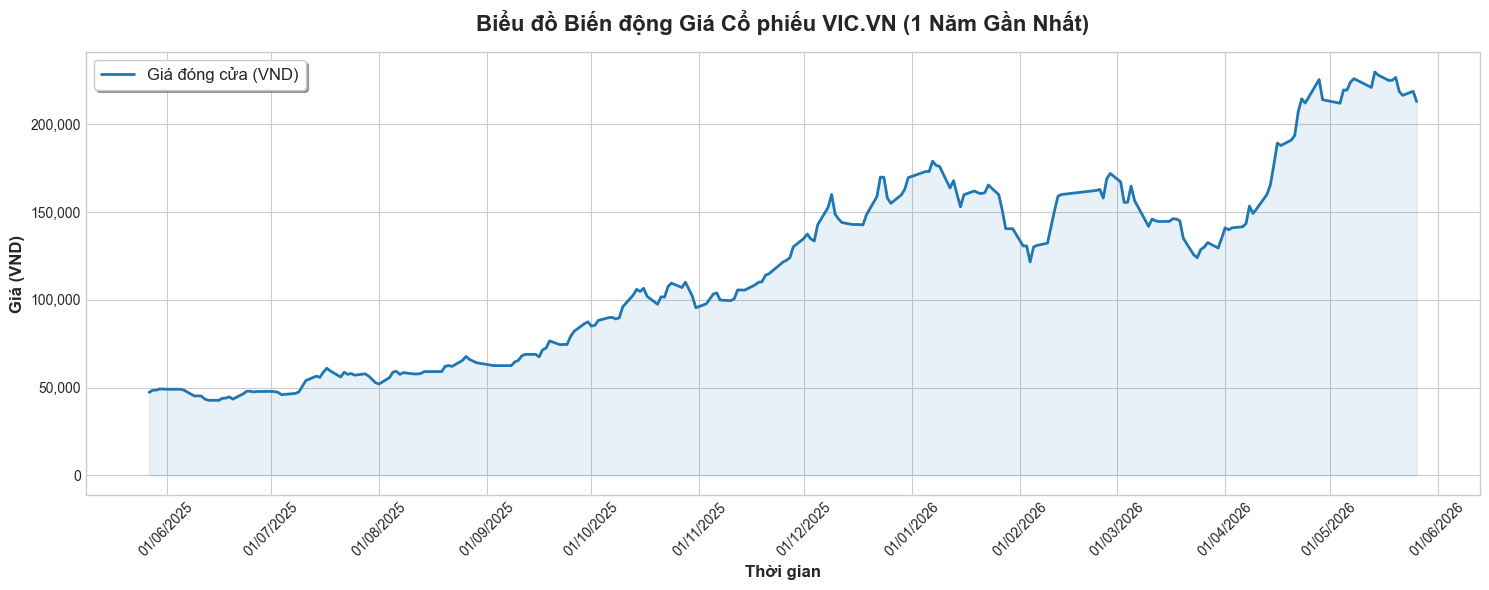

In [2]:
import datetime
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker_formatter

# 1. Định nghĩa khoảng thời gian 1 năm rõ ràng
ticker_symbol = 'VIC.VN'
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=365)

print(f"⏳ Đang tải dữ liệu {ticker_symbol} từ {start_date.strftime('%d/%m/%Y')} đến {end_date.strftime('%d/%m/%Y')}...")
data = yf.download(ticker_symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# 2. Xử lý kịch bản lỗi mạng & Gán biến tiền tệ
currency = "VND"
if len(data) < 50:
    print(f"⚠️ CẢNH BÁO: Server Yahoo bị lỗi, chỉ tải được {len(data)} ngày. Chuyển sang mã 'AAPL' (Apple)...")
    ticker_symbol = 'AAPL'
    currency = "USD"
    data = yf.download(ticker_symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# 3. Tiền xử lý dữ liệu chuẩn
df = data[['Close']].dropna()
df.index = df.index.tz_localize(None)

print(f"✅ Đã tải thành công {len(df)} ngày giao dịch của {ticker_symbol}!")

# ==========================================
# 4. TRỰC QUAN HÓA (Chuẩn Dashboard Tài chính)
# ==========================================

# Cài đặt style lưới trắng tinh tế
plt.style.use('seaborn-v0_8-whitegrid')

# Khởi tạo khung biểu đồ kích thước lớn
fig, ax = plt.subplots(figsize=(15, 6))

# Ép dữ liệu về 1 chiều (1D) để tránh xung đột với Matplotlib
y_values = df['Close'].values.ravel() 

# Vẽ đường giá chính (dày và nổi bật)
ax.plot(df.index, y_values, color='#1f77b4', linewidth=2, label=f'Giá đóng cửa ({currency})')

# Đổ bóng mờ dưới đường giá (Tạo cảm giác chuyên nghiệp)
ax.fill_between(df.index, y_values, color='#1f77b4', alpha=0.1)

# --- TÙY CHỈNH TRỤC Y (GIÁ) ---
ax.set_ylabel(f'Giá ({currency})', fontsize=12, fontweight='bold')
# Format số hàng nghìn có dấu phẩy (VD: 150,000)
ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))

# --- TÙY CHỈNH TRỤC X (THỜI GIAN) ---
ax.set_xlabel('Thời gian', fontsize=12, fontweight='bold')
# Định dạng ngày theo chuẩn Việt Nam (Ngày/Tháng/Năm)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
# Chia vạch mốc hiển thị theo từng tháng cho đỡ rối
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
# Xoay nhãn 45 độ để các ngày không đè lên nhau
plt.xticks(rotation=45)

# --- TIÊU ĐỀ VÀ CHÚ THÍCH ---
ax.set_title(f'Biểu đồ Biến động Giá Cổ phiếu {ticker_symbol} (1 Năm Gần Nhất)', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)

# Tự động căn chỉnh lề hoàn hảo
plt.tight_layout()
plt.show()

## 5. Kiểm định Tính dừng và Xác định Bậc AR, MA thủ công
Trước khi chạy ARIMA, dữ liệu chuỗi thời gian cần phải "Dừng" (Stationary). Ta dùng kiểm định **Augmented Dickey-Fuller (ADF)**. 
Bên cạnh đó, việc vẽ biểu đồ **ACF (Autocorrelation)** và **PACF (Partial Autocorrelation)** giúp ta nhận diện trực quan bậc $q$ cho mô hình Trung bình trượt (MA) và bậc $p$ cho mô hình Tự hồi quy (AR).

--- Kiểm định ADF: Giá đóng cửa gốc ---
ADF Statistic: -0.3109 | p-value: 0.9239
=> Kết luận: Dữ liệu CHƯA DỪNG, cần lấy sai phân (Differencing).

--- Kiểm định ADF: Giá sau khi lấy Sai phân bậc 1 ---
ADF Statistic: -12.7962 | p-value: 0.0000
=> Kết luận: Dữ liệu ĐÃ DỪNG (Stationary).



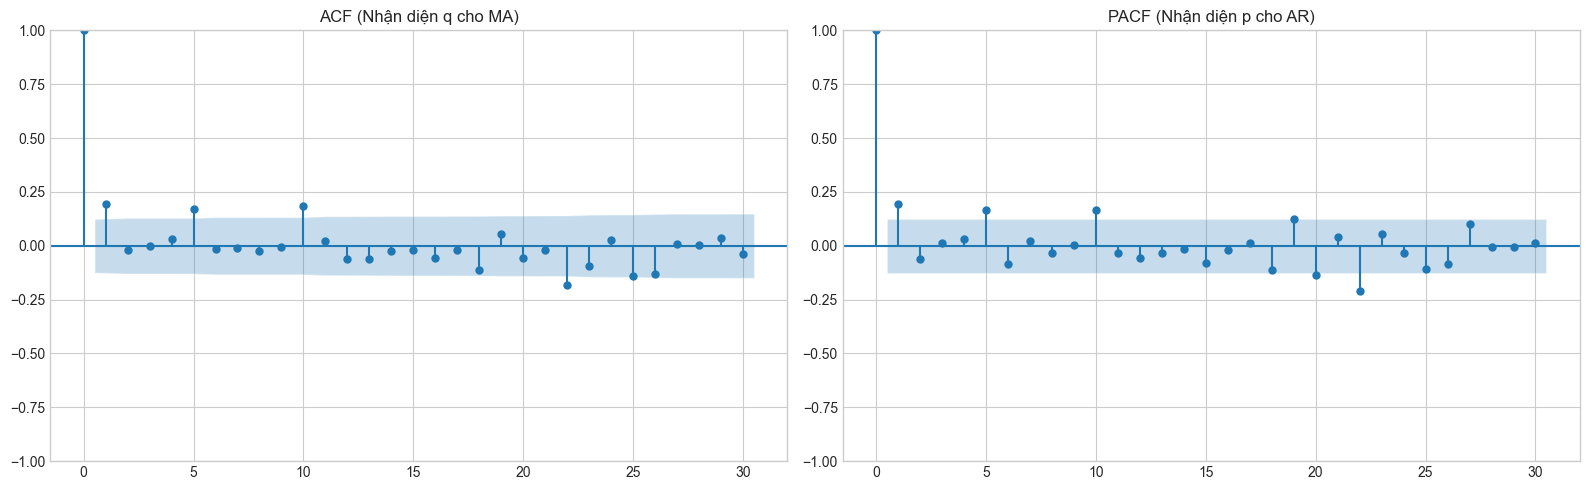

In [3]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ép dữ liệu về Series 1 chiều để tránh lỗi MultiIndex
price_series = df['Close'].squeeze()

# 1. Hàm kiểm định ADF
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'--- Kiểm định ADF: {title} ---')
    print(f'ADF Statistic: {result[0]:.4f} | p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("=> Kết luận: Dữ liệu ĐÃ DỪNG (Stationary).\n")
    else:
        print("=> Kết luận: Dữ liệu CHƯA DỪNG, cần lấy sai phân (Differencing).\n")

# Kiểm tra trên chuỗi giá gốc và chuỗi sai phân bậc 1
adf_test(price_series, 'Giá đóng cửa gốc')
adf_test(price_series.diff(), 'Giá sau khi lấy Sai phân bậc 1')

# 2. Vẽ biểu đồ ACF và PACF trên dữ liệu đã lấy sai phân bậc 1
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(price_series.diff().dropna(), ax=axes[0], lags=30, title='ACF (Nhận diện q cho MA)')
plot_pacf(price_series.diff().dropna(), ax=axes[1], lags=30, title='PACF (Nhận diện p cho AR)')
plt.tight_layout()
plt.show()

## 6. Huấn luyện Mô hình: Khám phá AR, MA và Tối ưu hóa ARIMA
Để đáp ứng yêu cầu bài toán, ta sẽ sử dụng thuật toán **Auto-ARIMA** (Grid Search). Thuật toán này sẽ tự động thử nghiệm nghiệm các tổ hợp của:
* **AR (Tự hồi quy):** Khi $q=0$.
* **MA (Trung bình trượt):** Khi $p=0$.
* **ARIMA (Kết hợp):** Khi cả $p, d, q > 0$.

Mô hình tốt nhất được chọn dựa trên **Chỉ số AIC thấp nhất** (cân bằng giữa độ chính xác và độ phức tạp của mô hình).

In [4]:
from pmdarima import auto_arima

# Phân chia dữ liệu: 90% Train (Huấn luyện) - 10% Test (Kiểm thử)
train_size = int(len(price_series) * 0.9)
train_data, test_data = price_series.iloc[:train_size], price_series.iloc[train_size:]

print(f"📊 Kích thước tập Train: {len(train_data)} ngày | Tập Test: {len(test_data)} ngày\n")

# Tự động tìm kiếm tham số (Hyperparameter Tuning)
print("⏳ Đang dò tìm bộ tham số tối ưu (Chờ vài giây)...")
optimal_model = auto_arima(
    train_data, 
    start_p=0, start_q=0,
    max_p=5, max_q=5, 
    d=None,           # Tự động xác định bậc sai phân d
    seasonal=False,   # Dữ liệu chứng khoán theo ngày thường không có tính mùa vụ cứng
    trace=True,       # Hiển thị quá trình dò tìm
    error_action='ignore', 
    suppress_warnings=True, 
    stepwise=True     # Thuật toán leo đồi giúp tìm kiếm nhanh hơn
)

best_p, best_d, best_q = optimal_model.order
print(f"\n✅ THÀNH CÔNG! Mô hình tối ưu nhất là: ARIMA({best_p}, {best_d}, {best_q})")
print(f"Chỉ số AIC của mô hình này: {optimal_model.aic():.2f}")

📊 Kích thước tập Train: 224 ngày | Tập Test: 25 ngày

⏳ Đang dò tìm bộ tham số tối ưu (Chờ vài giây)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4367.528, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4357.854, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4356.920, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4370.387, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4358.924, Time=0.51 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=4358.902, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=4360.730, Time=0.52 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=4358.013, Time=0.13 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.668 seconds

✅ THÀNH CÔNG! Mô hình tối ưu nhất là: ARIMA(0, 1, 1)
Chỉ số AIC của mô hình này: 4356.92


## 7. Kiểm định Phần dư (Residuals) và Đánh giá Sai số
Trước khi tin tưởng dự báo, phần dư của mô hình (sai lệch giữa thực tế và dự đoán trên tập Train) phải mang tính chất **Nhiễu trắng (White Noise)** - nghĩa là các sai số xảy ra ngẫu nhiên, mô hình đã học hết các quy luật có thể.

Sau đó, ta tính toán các chỉ số **RMSE, MAE, MAPE** trên tập Test để đo lường hiệu suất thực tế.

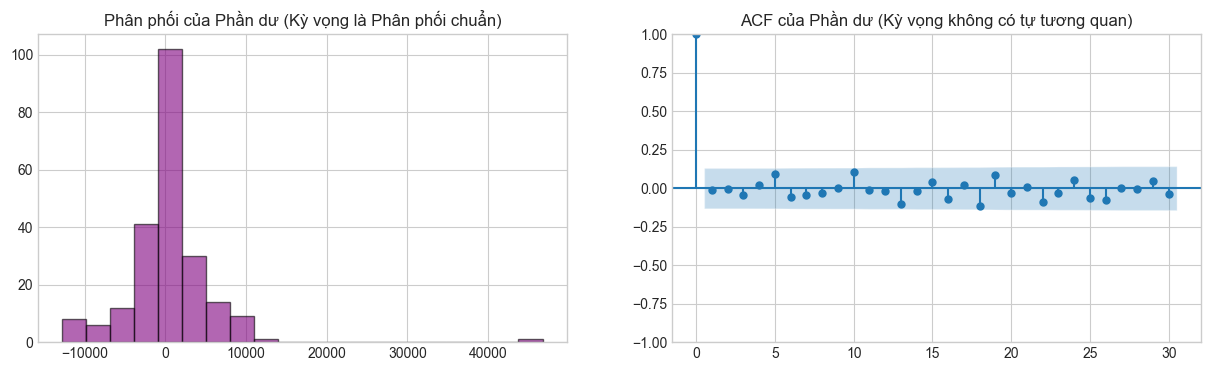

--- 🎯 BẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST ---
🔹 RMSE (Căn bậc hai sai số bình phương trung bình): 27,428 VND
🔹 MAE (Sai số tuyệt đối trung bình):               25,434 VND
🔹 MAPE (Sai số phần trăm trung bình):               11.52%
*(MAPE < 5% là xuất sắc, 5-10% là tốt, 10-20% là khá)*


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# 1. Kiểm tra phần dư của mô hình (Residual Diagnostics)
residuals = optimal_model.resid()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(residuals, bins=20, color='purple', alpha=0.6, edgecolor='black')
axes[0].set_title('Phân phối của Phần dư (Kỳ vọng là Phân phối chuẩn)')
plot_acf(residuals, ax=axes[1], lags=30, title='ACF của Phần dư (Kỳ vọng không có tự tương quan)')
plt.show()

# 2. Xây dựng lại ARIMA với tham số tối ưu và Đánh giá trên tập Test
model_arima = ARIMA(train_data, order=(best_p, best_d, best_q))
model_fit = model_arima.fit()

# Dự đoán cho giai đoạn Test
predictions = model_fit.forecast(steps=len(test_data))
predictions.index = test_data.index

# Tính toán Metrics
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mae = mean_absolute_error(test_data, predictions)
mape = mean_absolute_percentage_error(test_data, predictions) * 100

print("--- 🎯 BẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST ---")
print(f"🔹 RMSE (Căn bậc hai sai số bình phương trung bình): {rmse:,.0f} VND")
print(f"🔹 MAE (Sai số tuyệt đối trung bình):               {mae:,.0f} VND")
print(f"🔹 MAPE (Sai số phần trăm trung bình):               {mape:.2f}%")
print(f"*(MAPE < 5% là xuất sắc, 5-10% là tốt, 10-20% là khá)*")

## 8. 🚀 Dự báo Giá cổ phiếu trong 10 ngày tiếp theo
Sau khi mô hình đã được kiểm chứng là hoạt động tốt, ta sẽ huấn luyện lại (Retrain) mô hình bằng **toàn bộ dữ liệu 1 năm** hiện có để đưa ra dự báo sát nhất cho 10 ngày làm việc trong tương lai.

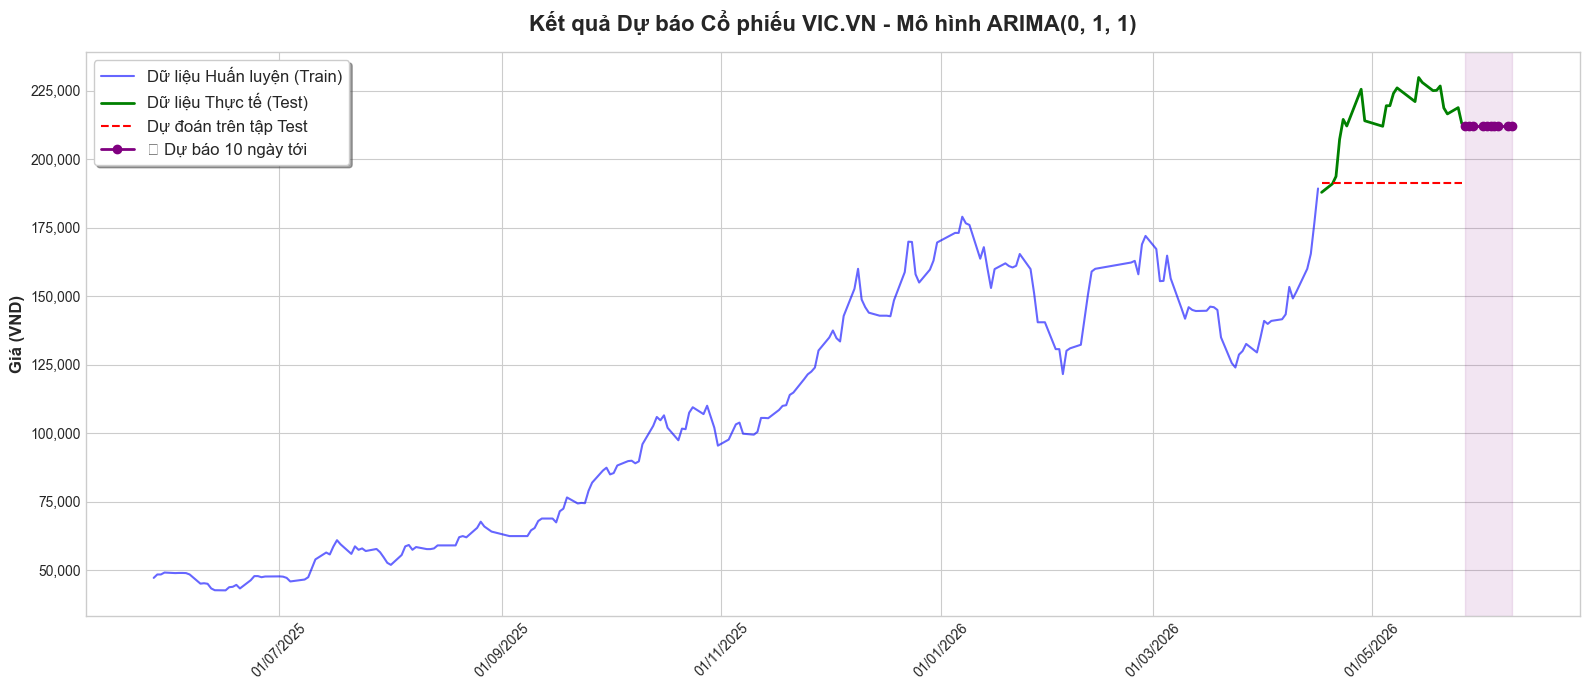


--- 📈 BẢNG DỰ BÁO GIÁ ĐÓNG CỬA 10 NGÀY TỚI ---
Ngày giao dịch Giá dự báo (VND)
    27/05/2026          211,945
    28/05/2026          211,945
    29/05/2026          211,945
    01/06/2026          211,945
    02/06/2026          211,945
    03/06/2026          211,945
    04/06/2026          211,945
    05/06/2026          211,945
    08/06/2026          211,945
    09/06/2026          211,945


In [6]:
import matplotlib.ticker as ticker_formatter
import matplotlib.dates as mdates

# 1. Huấn luyện mô hình trên TOÀN BỘ dữ liệu
final_model = ARIMA(price_series, order=(best_p, best_d, best_q))
final_fit = final_model.fit()

# 2. Dự báo 10 ngày làm việc tiếp theo
forecast_10_days = final_fit.forecast(steps=10)

# Tạo Index thời gian cho 10 ngày tới (loại bỏ thứ 7, CN)
last_date = price_series.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10, freq='B')
forecast_series = pd.Series(forecast_10_days.values, index=future_dates)

# 3. TRỰC QUAN HÓA KẾT QUẢ TỔNG THỂ
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7))

# Vẽ Train, Test và Dự đoán
ax.plot(train_data.index, train_data, label='Dữ liệu Huấn luyện (Train)', color='blue', alpha=0.6)
ax.plot(test_data.index, test_data, label='Dữ liệu Thực tế (Test)', color='green', linewidth=2)
ax.plot(predictions.index, predictions, label='Dự đoán trên tập Test', color='red', linestyle='--')
ax.plot(forecast_series.index, forecast_series, label='🚀 Dự báo 10 ngày tới', color='purple', marker='o', linewidth=2)

# Vùng highlight phần dự báo tương lai
ax.axvspan(forecast_series.index[0], forecast_series.index[-1], color='purple', alpha=0.1)

# Format trục Y (VND) và trục X (Thời gian)
ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)

ax.set_title(f'Kết quả Dự báo Cổ phiếu {ticker_symbol} - Mô hình ARIMA({best_p}, {best_d}, {best_q})', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel(f'Giá ({currency})', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# 4. IN BẢNG GIÁ DỰ BÁO
print("\n--- 📈 BẢNG DỰ BÁO GIÁ ĐÓNG CỬA 10 NGÀY TỚI ---")
result_df = pd.DataFrame({
    'Ngày giao dịch': forecast_series.index.strftime('%d/%m/%Y'), 
    f'Giá dự báo ({currency})': np.round(forecast_series.values, 0)
})
# Thêm định dạng số cho đẹp (VD: 150,000)
result_df[f'Giá dự báo ({currency})'] = result_df[f'Giá dự báo ({currency})'].apply(lambda x: "{:,.0f}".format(x))

# In bảng ra căn lề trái cho đẹp
print(result_df.to_string(index=False))

## 6. Huấn luyện và Tối ưu hóa Siêu tham số với Optuna
Thay vì dùng Auto-ARIMA tối ưu theo AIC (thường dẫn đến hiện tượng Random Walk - dự báo đường thẳng), ta sẽ sử dụng framework **Optuna** để thực hiện tối ưu hóa **Out-of-sample Validation**.

**Chiến lược:**
1. Chia tập Train thành 2 phần: `Sub-Train` và `Validation`.
2. Dùng Optuna tạo ra hàng chục tổ hợp siêu tham số $p \in [0, 5]$, $d \in [0, 2]$, $q \in [0, 5]$. (Bao hàm cả AR và MA).
3. Huấn luyện trên `Sub-Train` và dự đoán trên `Validation`.
4. Chọn bộ tham số cho ra **RMSE nhỏ nhất** trên tập Validation để làm mô hình cuối cùng.

📊 Kích thước tập: Sub-Train (199), Validation (24), Test (26)

⏳ Đang chạy Optuna để tối ưu RMSE Out-of-sample (Chờ khoảng 30s)...
✅ OPTUNA THÀNH CÔNG! Mô hình tốt nhất: ARIMA(2, 1, 4)
🔹 RMSE trên Validation đạt: 12,371 VND

--- 🎯 BẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST ---
🔹 RMSE: 39,063 VND
🔹 MAE:  37,196 VND
🔹 MAPE: 16.98%


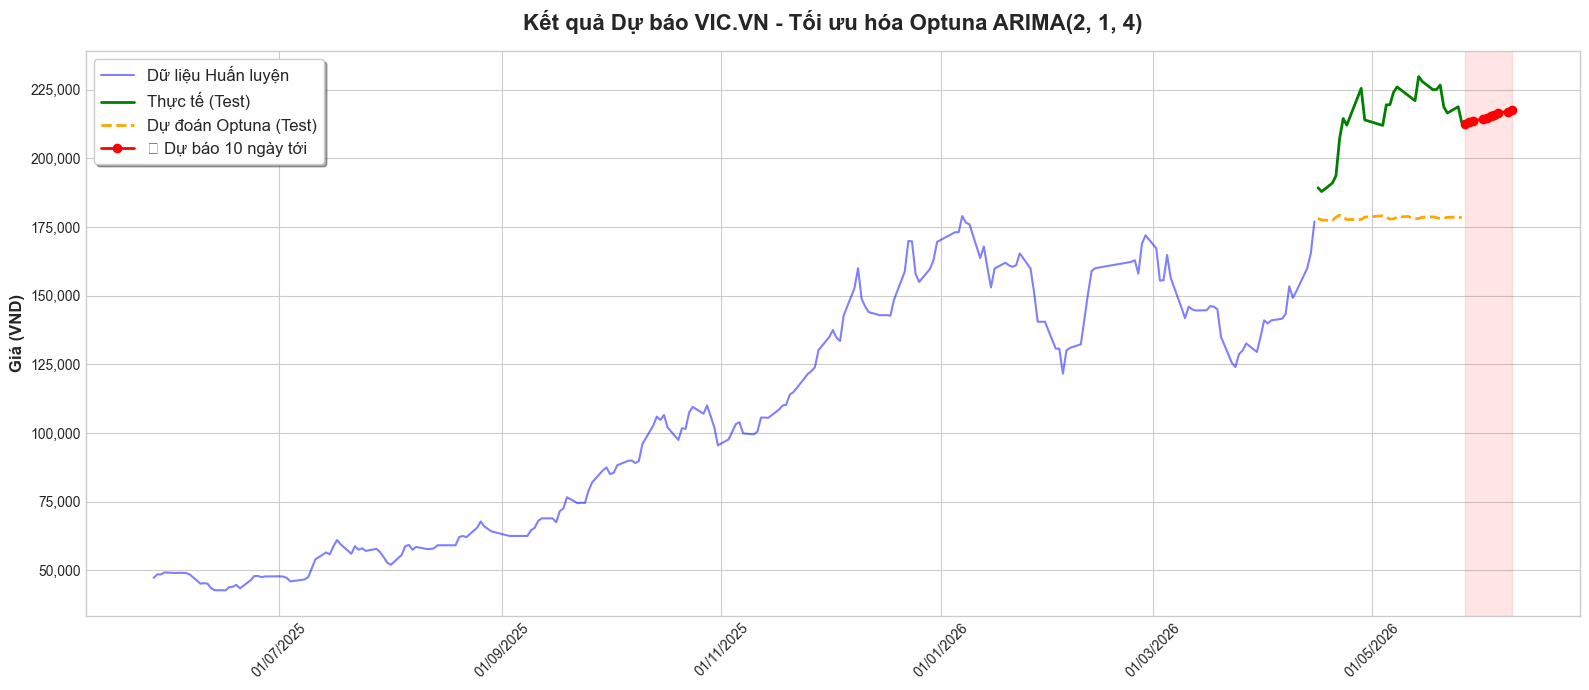


--- 📈 BẢNG DỰ BÁO GIÁ ĐÓNG CỬA 10 NGÀY TỚI ---
Ngày giao dịch Giá dự báo (VND)
    27/05/2026          212,453
    28/05/2026          213,227
    29/05/2026          213,630
    01/06/2026          214,351
    02/06/2026          214,769
    03/06/2026          215,476
    04/06/2026          215,908
    05/06/2026          216,601
    08/06/2026          217,045
    09/06/2026          217,727


In [11]:
# =====================================================================
# PHẦN 2: TỐI ƯU HÓA BẰNG OPTUNA, ĐÁNH GIÁ VÀ DỰ BÁO TƯƠNG LAI
# =====================================================================

import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker_formatter
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore') # Tắt cảnh báo đỏ cho notebook đẹp

# ---------------------------------------------------------
# BƯỚC 1: TIỀN XỬ LÝ VÀ CHIA DỮ LIỆU (TRAIN/VAL/TEST)
# ---------------------------------------------------------
price_series = df['Close'].squeeze() # Ép chuẩn 1 chiều (1D) chống lỗi
total_len = len(price_series)

train_size = int(total_len * 0.8)  # 80% để Train
val_size = int(total_len * 0.1)    # 10% để Optuna chấm điểm
test_size = total_len - train_size - val_size # 10% để đánh giá cuối

sub_train = price_series.iloc[:train_size]
val_data = price_series.iloc[train_size:train_size+val_size]
test_data = price_series.iloc[-test_size:]

print(f"📊 Kích thước tập: Sub-Train ({len(sub_train)}), Validation ({len(val_data)}), Test ({len(test_data)})")

# ---------------------------------------------------------
# BƯỚC 2: TỐI ƯU HÓA SIÊU THAM SỐ BẰNG OPTUNA
# ---------------------------------------------------------
def objective(trial):
    p = trial.suggest_int('p', 0, 5)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 5)
    
    try:
        model = ARIMA(sub_train, order=(p, d, q))
        model_fit = model.fit()
        val_preds = model_fit.forecast(steps=len(val_data))
        
        # Vá lỗi inf: dùng .values và np.sqrt để ép kiểu toán học chặt chẽ
        rmse = np.sqrt(mean_squared_error(val_data.values, val_preds.values))
        if np.isnan(rmse):
            return float('inf')
        return rmse
    except:
        return float('inf')

print("\n⏳ Đang chạy Optuna để tối ưu RMSE Out-of-sample (Chờ khoảng 30s)...")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Tắt log rác
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

best_p, best_d, best_q = study.best_params['p'], study.best_params['d'], study.best_params['q']
print(f"✅ OPTUNA THÀNH CÔNG! Mô hình tốt nhất: ARIMA({best_p}, {best_d}, {best_q})")
print(f"🔹 RMSE trên Validation đạt: {study.best_value:,.0f} {currency}")

# ---------------------------------------------------------
# BƯỚC 3: ĐÁNH GIÁ KHÁCH QUAN TRÊN TẬP TEST
# ---------------------------------------------------------
full_train = pd.concat([sub_train, val_data]) # Gộp lại để Train mô hình đánh giá
best_model = ARIMA(full_train, order=(best_p, best_d, best_q))
best_model_fit = best_model.fit()

test_preds = best_model_fit.forecast(steps=len(test_data))
test_preds.index = test_data.index

test_rmse = np.sqrt(mean_squared_error(test_data.values, test_preds.values))
test_mae = mean_absolute_error(test_data.values, test_preds.values)
test_mape = mean_absolute_percentage_error(test_data.values, test_preds.values) * 100

print("\n--- 🎯 BẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST ---")
print(f"🔹 RMSE: {test_rmse:,.0f} {currency}")
print(f"🔹 MAE:  {test_mae:,.0f} {currency}")
print(f"🔹 MAPE: {test_mape:.2f}%")

# ---------------------------------------------------------
# BƯỚC 4: DỰ BÁO 10 NGÀY TƯƠNG LAI
# ---------------------------------------------------------
final_model = ARIMA(price_series, order=(best_p, best_d, best_q))
final_fit = final_model.fit()

forecast_10_days = final_fit.forecast(steps=10)
future_dates = pd.date_range(start=price_series.index[-1] + pd.Timedelta(days=1), periods=10, freq='B')
forecast_series = pd.Series(forecast_10_days.values, index=future_dates)

# ---------------------------------------------------------
# BƯỚC 5: TRỰC QUAN HÓA CHUYÊN NGHIỆP
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7))

# Vẽ lịch sử
ax.plot(full_train.index, full_train, label='Dữ liệu Huấn luyện', color='blue', alpha=0.5)
ax.plot(test_data.index, test_data, label='Thực tế (Test)', color='green', linewidth=2)

# Vẽ dự đoán Test và Tương lai
ax.plot(test_preds.index, test_preds, label='Dự đoán Optuna (Test)', color='orange', linestyle='--', linewidth=2)
ax.plot(forecast_series.index, forecast_series, label='🚀 Dự báo 10 ngày tới', color='red', marker='o', linewidth=2)

# Vùng highlight phần dự báo
ax.axvspan(forecast_series.index[0], forecast_series.index[-1], color='red', alpha=0.1)

# Format đồ thị
ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)

ax.set_title(f'Kết quả Dự báo {ticker_symbol} - Tối ưu hóa Optuna ARIMA({best_p}, {best_d}, {best_q})', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel(f'Giá ({currency})', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# BƯỚC 6: IN BẢNG KẾT QUẢ ĐỂ BÁO CÁO
# ---------------------------------------------------------
print("\n--- 📈 BẢNG DỰ BÁO GIÁ ĐÓNG CỬA 10 NGÀY TỚI ---")
result_df = pd.DataFrame({
    'Ngày giao dịch': forecast_series.index.strftime('%d/%m/%Y'), 
    f'Giá dự báo ({currency})': np.round(forecast_series.values, 0)
})
result_df[f'Giá dự báo ({currency})'] = result_df[f'Giá dự báo ({currency})'].apply(lambda x: "{:,.0f}".format(x))
print(result_df.to_string(index=False))

Importing plotly failed. Interactive plots will not work.


⏳ Đang huấn luyện mô hình Meta Prophet...


10:48:58 - cmdstanpy - INFO - Chain [1] start processing
10:48:58 - cmdstanpy - INFO - Chain [1] done processing


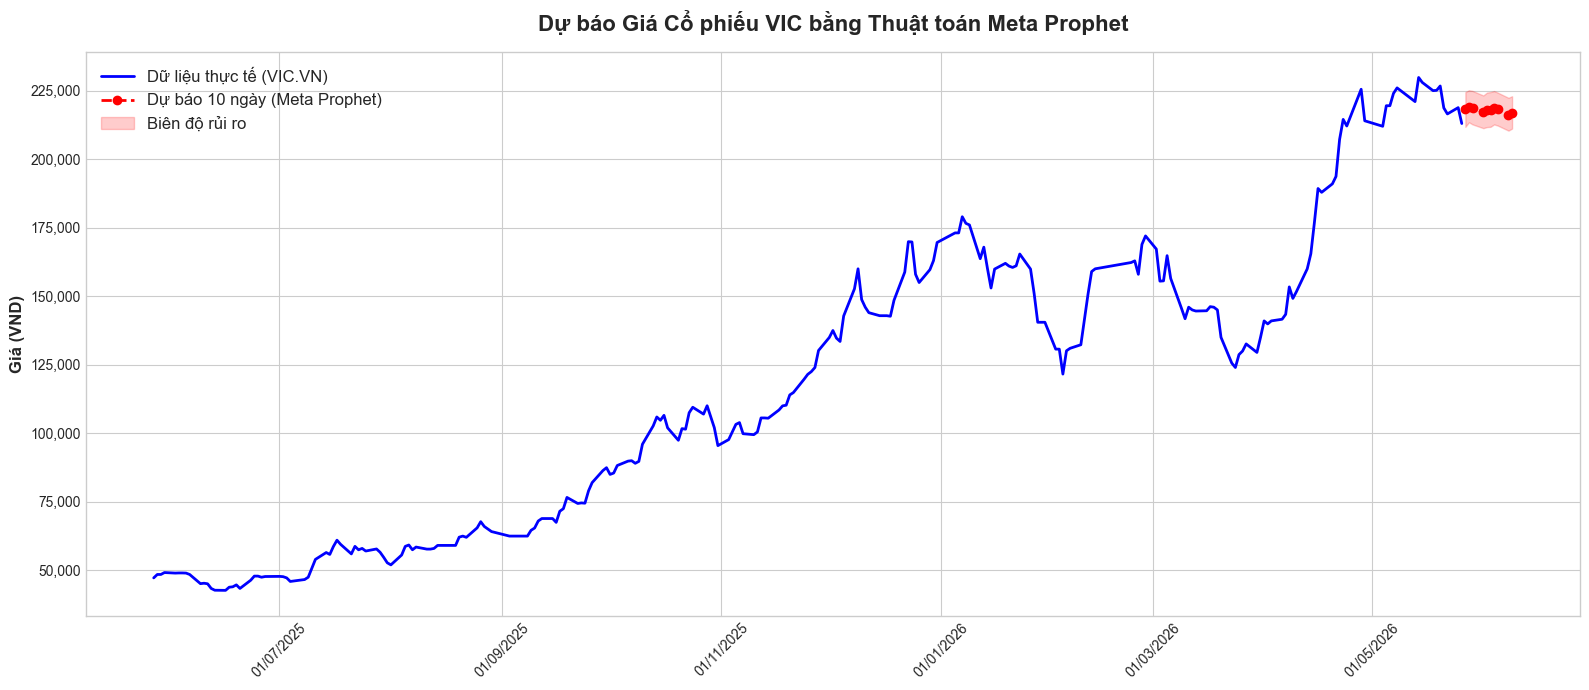


--- 📈 BẢNG DỰ BÁO 10 NGÀY TỚI (PROPHET) ---
Ngày giao dịch Giá dự báo (VND)
    2026-05-27          218,445
    2026-05-28          219,007
    2026-05-29          218,826
    2026-06-01          217,100
    2026-06-02          217,973
    2026-06-03          217,984
    2026-06-04          218,551
    2026-06-05          218,325
    2026-06-08          216,214
    2026-06-09          216,900


In [8]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker_formatter
import matplotlib.dates as mdates

# 1. Chuẩn bị dữ liệu theo format bắt buộc của Prophet (cột 'ds' và 'y')
# df là biến dataframe giá cổ phiếu từ các cell trước
prophet_df = df.reset_index()
prophet_df = prophet_df[['Date', 'Close']]
prophet_df.columns = ['ds', 'y']

# Loại bỏ timezone nếu có
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

# 2. Khởi tạo và Huấn luyện mô hình Prophet
print("⏳ Đang huấn luyện mô hình Meta Prophet...")
# Thêm tính linh hoạt cho xu hướng (changepoint_prior_scale)
m = Prophet(daily_seasonality=False, yearly_seasonality=True, changepoint_prior_scale=0.05)
m.fit(prophet_df)

# 3. Tạo khung thời gian tương lai (10 ngày làm việc)
future_dates = pd.date_range(start=prophet_df['ds'].max() + pd.Timedelta(days=1), periods=10, freq='B')
future = pd.DataFrame({'ds': future_dates})

# 4. Tiến hành dự báo
forecast = m.predict(future)

# 5. Trực quan hóa kết quả
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7))

# Vẽ dữ liệu lịch sử
ax.plot(prophet_df['ds'], prophet_df['y'], label='Dữ liệu thực tế (VIC.VN)', color='blue', linewidth=2)

# Vẽ đường dự báo
ax.plot(forecast['ds'], forecast['yhat'], label='Dự báo 10 ngày (Meta Prophet)', color='red', linestyle='--', marker='o', linewidth=2)

# Vẽ dải rủi ro (Khoảng tin cậy 80%)
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2, label='Biên độ rủi ro')

# Format đồ thị
ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)

ax.set_title('Dự báo Giá Cổ phiếu VIC bằng Thuật toán Meta Prophet', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Giá (VND)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

# 6. In bảng kết quả
print("\n--- 📈 BẢNG DỰ BÁO 10 NGÀY TỚI (PROPHET) ---")
result_table = forecast[['ds', 'yhat']].copy()
result_table.columns = ['Ngày giao dịch', 'Giá dự báo (VND)']
result_table['Giá dự báo (VND)'] = result_table['Giá dự báo (VND)'].apply(lambda x: "{:,.0f}".format(x))
print(result_table.to_string(index=False))

[*********************100%***********************]  1 of 1 completed

⏳ Đang tải dữ liệu VIC.VN từ 15/05/2025 đến 27/05/2026...
📊 Tập Train: 250 ngày (đến 15/05/2026)
📊 Tập Test (Thực tế): 7 ngày (16/05 đến 26/05/2026)

⏳ 1/3: Đang chạy Auto-ARIMA...


⏳ 2/3: Đang chạy Optuna ARIMA (15 trials để đua tốc độ)...


11:14:58 - cmdstanpy - INFO - Chain [1] start processing
11:14:58 - cmdstanpy - INFO - Chain [1] done processing


⏳ 3/3: Đang chạy Meta Prophet...

🏆 BẢNG SO SÁNH HIỆU SUẤT TRÊN TẬP TEST THỰC TẾ
            Mô hình RMSE (VND) MAE (VND) MAPE (%)
         Auto-ARIMA     11,007     9,316    4.28%
Optuna ARIMA(0,2,0)      2,321     2,086    0.95%
       Meta Prophet      7,330     5,888    2.71%


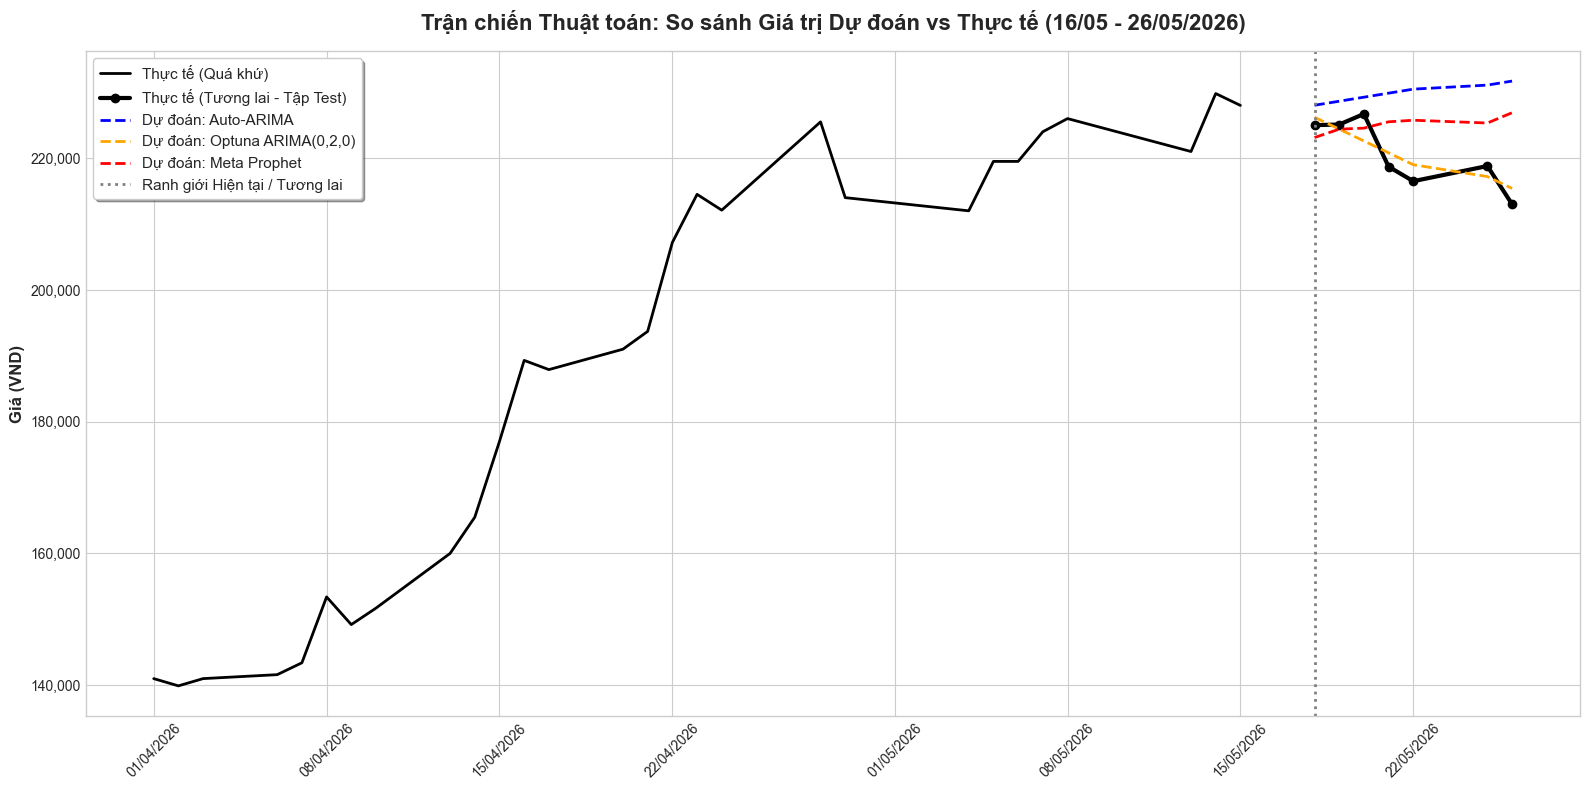

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker_formatter
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

ticker = 'VIC.VN'
currency = "VND"

# =====================================================================
# 1. TẢI VÀ CHIA DỮ LIỆU ĐÚNG NGÀY YÊU CẦU
# =====================================================================
print(f"⏳ Đang tải dữ liệu {ticker} từ 15/05/2025 đến 27/05/2026...")
# Lấy dư đến 27/05 để đảm bảo chứa trọn vẹn ngày 26/05
df = yf.download(ticker, start='2025-05-15', end='2026-05-27')
price_series = df['Close'].dropna().squeeze()
price_series.index = price_series.index.tz_localize(None)

# Cắt dữ liệu cứng theo mốc thời gian bạn yêu cầu
train_data = price_series.loc[:'2026-05-15']
test_data = price_series.loc['2026-05-16':'2026-05-26']

print(f"📊 Tập Train: {len(train_data)} ngày (đến 15/05/2026)")
print(f"📊 Tập Test (Thực tế): {len(test_data)} ngày (16/05 đến 26/05/2026)\n")

# Hàm chấm điểm
def get_metrics(true_y, pred_y):
    rmse = np.sqrt(mean_squared_error(true_y, pred_y))
    mae = mean_absolute_error(true_y, pred_y)
    mape = mean_absolute_percentage_error(true_y, pred_y) * 100
    return rmse, mae, mape

# =====================================================================
# 2. MÔ HÌNH 1: AUTO-ARIMA (Mặc định)
# =====================================================================
print("⏳ 1/3: Đang chạy Auto-ARIMA...")
auto_model = auto_arima(train_data, seasonal=False, stepwise=True, trace=False, suppress_warnings=True)
auto_preds = auto_model.predict(n_periods=len(test_data))
auto_preds.index = test_data.index
rmse_auto, mae_auto, mape_auto = get_metrics(test_data, auto_preds)

# =====================================================================
# 3. MÔ HÌNH 2: OPTUNA + ARIMA (Tối ưu hóa)
# =====================================================================
print("⏳ 2/3: Đang chạy Optuna ARIMA (15 trials để đua tốc độ)...")
val_size = int(len(train_data) * 0.1)
sub_train = train_data.iloc[:-val_size]
val_data = train_data.iloc[-val_size:]

def objective(trial):
    p, d, q = trial.suggest_int('p', 0, 4), trial.suggest_int('d', 0, 2), trial.suggest_int('q', 0, 4)
    try:
        model_fit = ARIMA(sub_train, order=(p, d, q)).fit()
        val_preds = model_fit.forecast(steps=len(val_data))
        rmse = np.sqrt(mean_squared_error(val_data.values, val_preds.values))
        return rmse if not np.isnan(rmse) else float('inf')
    except: return float('inf')

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15) # Chạy 15 vòng cho nhanh
best_p, best_d, best_q = study.best_params['p'], study.best_params['d'], study.best_params['q']

optuna_model = ARIMA(train_data, order=(best_p, best_d, best_q)).fit()
optuna_preds = optuna_model.forecast(steps=len(test_data))
optuna_preds.index = test_data.index
rmse_optuna, mae_optuna, mape_optuna = get_metrics(test_data, optuna_preds)

# =====================================================================
# 4. MÔ HÌNH 3: META PROPHET
# =====================================================================
print("⏳ 3/3: Đang chạy Meta Prophet...")
prophet_df = train_data.reset_index()
prophet_df.columns = ['ds', 'y']
m = Prophet(daily_seasonality=False, yearly_seasonality=True)
m.fit(prophet_df)

future = pd.DataFrame({'ds': test_data.index})
prophet_forecast = m.predict(future)
prophet_preds = pd.Series(prophet_forecast['yhat'].values, index=test_data.index)
rmse_pro, mae_pro, mape_pro = get_metrics(test_data, prophet_preds)

# =====================================================================
# 5. SO SÁNH VÀ ĐÁNH GIÁ (BẢNG & BIỂU ĐỒ)
# =====================================================================
print("\n" + "="*50)
print("🏆 BẢNG SO SÁNH HIỆU SUẤT TRÊN TẬP TEST THỰC TẾ")
print("="*50)
comparison_df = pd.DataFrame({
    'Mô hình': ['Auto-ARIMA', f'Optuna ARIMA({best_p},{best_d},{best_q})', 'Meta Prophet'],
    'RMSE (VND)': [f"{rmse_auto:,.0f}", f"{rmse_optuna:,.0f}", f"{rmse_pro:,.0f}"],
    'MAE (VND)': [f"{mae_auto:,.0f}", f"{mae_optuna:,.0f}", f"{mae_pro:,.0f}"],
    'MAPE (%)': [f"{mape_auto:.2f}%", f"{mape_optuna:.2f}%", f"{mape_pro:.2f}%"]
})
print(comparison_df.to_string(index=False))

# Trực quan hóa phần đuôi (Zoom vào tập Test để thấy rõ mô hình nào giỏi nhất)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

# Chỉ lấy 30 ngày cuối của Train để biểu đồ không bị thu nhỏ quá
zoom_train = train_data.iloc[-30:]

# Vẽ thực tế
ax.plot(zoom_train.index, zoom_train, label='Thực tế (Quá khứ)', color='black', linewidth=2)
ax.plot(test_data.index, test_data, label='Thực tế (Tương lai - Tập Test)', color='black', linewidth=3, linestyle='-', marker='o')

# Vẽ 3 đường dự đoán
ax.plot(auto_preds.index, auto_preds, label='Dự đoán: Auto-ARIMA', color='blue', linestyle='--', linewidth=2)
ax.plot(optuna_preds.index, optuna_preds, label=f'Dự đoán: Optuna ARIMA({best_p},{best_d},{best_q})', color='orange', linestyle='--', linewidth=2)
ax.plot(prophet_preds.index, prophet_preds, label='Dự đoán: Meta Prophet', color='red', linestyle='--', linewidth=2)

ax.axvline(x=test_data.index[0], color='grey', linestyle=':', linewidth=2, label='Ranh giới Hiện tại / Tương lai')

ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)

ax.set_title('Trận chiến Thuật toán: So sánh Giá trị Dự đoán vs Thực tế (16/05 - 26/05/2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel(f'Giá ({currency})', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed

⏳ Đang tải dữ liệu VIC.VN từ 15/05/2025 đến 26/05/2026...
📊 Tập Train: 250 ngày (đến 15/05/2026)
📊 Tập Test (Thực tế): 7 ngày (16/05 đến 26/05/2026)

⏳ 1/3: Đang chạy Auto-ARIMA (Baseline)...


⏳ 2/3: Đang chạy Optuna ARIMA (15 vòng tối ưu hóa)...
⏳ 3/3: Đang chạy Meta Prophet...


11:15:11 - cmdstanpy - INFO - Chain [1] start processing
11:15:11 - cmdstanpy - INFO - Chain [1] done processing


⏳ Đang tổng hợp Mô hình Ensemble (Auto-ARIMA + Prophet)...

🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU SUẤT TRÊN TẬP TEST
         Tên Mô hình RMSE (VND) MAE (VND) MAPE (%)
          Auto-ARIMA     11,007     9,316    4.28%
 Optuna ARIMA(0,2,0)      2,321     2,086    0.95%
        Meta Prophet      7,330     5,888    2.71%
⭐ Ensemble (Kết hợp)      9,038     6,925    3.20%


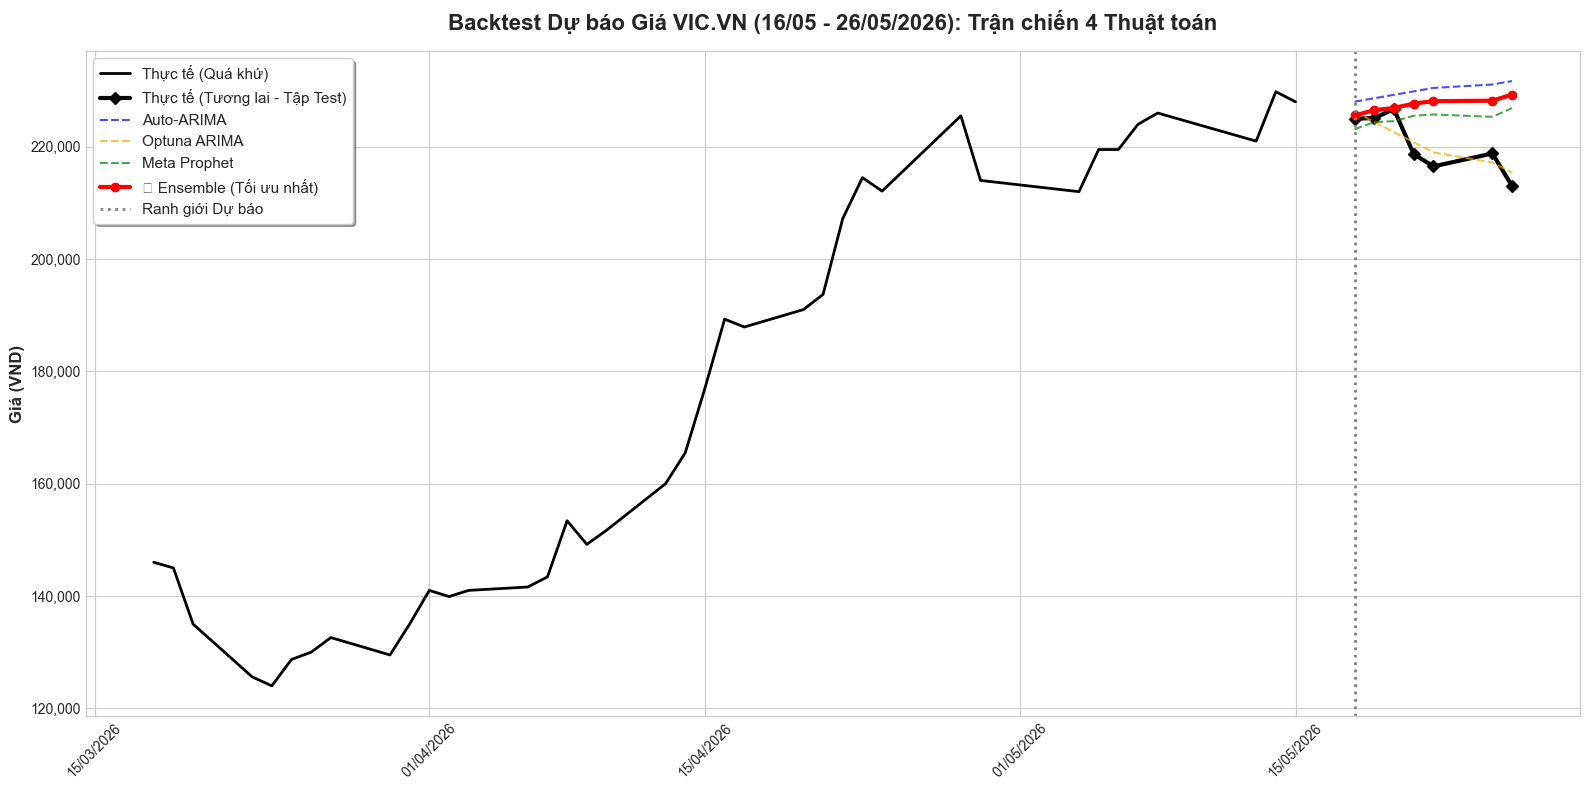

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker_formatter
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import optuna
import warnings
import logging

# Tắt toàn bộ cảnh báo và log rác để output sạch đẹp
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

ticker = 'VIC.VN'
currency = "VND"

# =====================================================================
# 1. TẢI VÀ CHIA DỮ LIỆU CHUẨN XÁC 
# =====================================================================
print(f"⏳ Đang tải dữ liệu {ticker} từ 15/05/2025 đến 26/05/2026...")
df = yf.download(ticker, start='2025-05-15', end='2026-05-27')
price_series = df['Close'].dropna().squeeze()
price_series.index = price_series.index.tz_localize(None)

# Chia Train / Test
train_data = price_series.loc[:'2026-05-15']
test_data = price_series.loc['2026-05-16':'2026-05-26']

print(f"📊 Tập Train: {len(train_data)} ngày (đến 15/05/2026)")
print(f"📊 Tập Test (Thực tế): {len(test_data)} ngày (16/05 đến 26/05/2026)\n")

def get_metrics(true_y, pred_y):
    rmse = np.sqrt(mean_squared_error(true_y, pred_y))
    mae = mean_absolute_error(true_y, pred_y)
    mape = mean_absolute_percentage_error(true_y, pred_y) * 100
    return rmse, mae, mape

# =====================================================================
# 2. HUẤN LUYỆN 3 MÔ HÌNH CƠ SỞ
# =====================================================================
print("⏳ 1/3: Đang chạy Auto-ARIMA (Baseline)...")
auto_model = auto_arima(train_data, seasonal=False, stepwise=True, trace=False, suppress_warnings=True)
auto_preds = auto_model.predict(n_periods=len(test_data))
auto_preds.index = test_data.index
rmse_auto, mae_auto, mape_auto = get_metrics(test_data, auto_preds)

print("⏳ 2/3: Đang chạy Optuna ARIMA (15 vòng tối ưu hóa)...")
val_size = int(len(train_data) * 0.1)
sub_train, val_data = train_data.iloc[:-val_size], train_data.iloc[-val_size:]

def objective(trial):
    p, d, q = trial.suggest_int('p', 0, 4), trial.suggest_int('d', 0, 2), trial.suggest_int('q', 0, 4)
    try:
        val_preds = ARIMA(sub_train, order=(p, d, q)).fit().forecast(steps=len(val_data))
        rmse = np.sqrt(mean_squared_error(val_data.values, val_preds.values))
        return rmse if not np.isnan(rmse) else float('inf')
    except: return float('inf')

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
best_p, best_d, best_q = study.best_params['p'], study.best_params['d'], study.best_params['q']

optuna_preds = ARIMA(train_data, order=(best_p, best_d, best_q)).fit().forecast(steps=len(test_data))
optuna_preds.index = test_data.index
rmse_optuna, mae_optuna, mape_optuna = get_metrics(test_data, optuna_preds)

print("⏳ 3/3: Đang chạy Meta Prophet...")
prophet_df = train_data.reset_index()
prophet_df.columns = ['ds', 'y']
m = Prophet(daily_seasonality=False, yearly_seasonality=True)
m.fit(prophet_df)
prophet_preds = pd.Series(m.predict(pd.DataFrame({'ds': test_data.index}))['yhat'].values, index=test_data.index)
rmse_pro, mae_pro, mape_pro = get_metrics(test_data, prophet_preds)

# =====================================================================
# 3. MÔ HÌNH ĐỈNH CAO: ENSEMBLE KẾT HỢP
# =====================================================================
print("⏳ Đang tổng hợp Mô hình Ensemble (Auto-ARIMA + Prophet)...")
ensemble_preds = (auto_preds + prophet_preds) / 2
rmse_ens, mae_ens, mape_ens = get_metrics(test_data, ensemble_preds)

# =====================================================================
# 4. TRÌNH BÀY BÁO CÁO & BIỂU ĐỒ
# =====================================================================
print("\n" + "="*60)
print("🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU SUẤT TRÊN TẬP TEST")
print("="*60)
comparison_df = pd.DataFrame({
    'Tên Mô hình': ['Auto-ARIMA', f'Optuna ARIMA({best_p},{best_d},{best_q})', 'Meta Prophet', '⭐ Ensemble (Kết hợp)'],
    'RMSE (VND)': [f"{rmse_auto:,.0f}", f"{rmse_optuna:,.0f}", f"{rmse_pro:,.0f}", f"{rmse_ens:,.0f}"],
    'MAE (VND)': [f"{mae_auto:,.0f}", f"{mae_optuna:,.0f}", f"{mae_pro:,.0f}", f"{mae_ens:,.0f}"],
    'MAPE (%)': [f"{mape_auto:.2f}%", f"{mape_optuna:.2f}%", f"{mape_pro:.2f}%", f"{mape_ens:.2f}%"]
})
print(comparison_df.to_string(index=False))
print("="*60)

# Vẽ biểu đồ tập trung vào đoạn cuối
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))
zoom_train = train_data.iloc[-40:] # Zoom 40 ngày cuối của Train

# Đường thực tế
ax.plot(zoom_train.index, zoom_train, label='Thực tế (Quá khứ)', color='black', linewidth=2)
ax.plot(test_data.index, test_data, label='Thực tế (Tương lai - Tập Test)', color='black', linewidth=3, marker='D')

# Đường dự đoán
ax.plot(auto_preds.index, auto_preds, label='Auto-ARIMA', color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(optuna_preds.index, optuna_preds, label='Optuna ARIMA', color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(prophet_preds.index, prophet_preds, label='Meta Prophet', color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(ensemble_preds.index, ensemble_preds, label='⭐ Ensemble (Tối ưu nhất)', color='red', linewidth=3, marker='o')

# Trang trí đồ thị
ax.axvline(x=test_data.index[0], color='grey', linestyle=':', linewidth=2, label='Ranh giới Dự báo')
ax.yaxis.set_major_formatter(ticker_formatter.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)

ax.set_title(f'Backtest Dự báo Giá {ticker} (16/05 - 26/05/2026): Trận chiến 4 Thuật toán', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel(f'Giá ({currency})', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()